# The Saturated Gas Plant

A crude unit's overhead makes two streams that are not yet products:

- a small **offgas** at near-atmospheric pressure;
- an **unstabilised naphtha** that still carries its propane and butanes.

The saturated gas plant turns them into products. It compresses the offgas, sweetens it,
recovers its C3+ into the naphtha, stabilises the naphtha by taking the LPG off the top, and
splits what is left into light and heavy naphtha. The C2- that remains is fuel gas.

This notebook runs that chain on the test crude used throughout `difflow_refinery`
(`examples/35_refinery_cdu_planning.ipynb`). Every column is a rigorous
`GasPlantColumn`: Naphtali-Sandholm MESH on Peng-Robinson, with O'Connell tray
efficiencies. The chain is:

1. the crude unit, with a partial condenser at 40 C;
2. a two-stage `GasCompressor` on the offgas, which knocks out a condensate between stages;
3. an `AmineTreater` on the compressed gas;
4. an `absorber_deethanizer`, with the unstabilised naphtha as lean oil;
5. a `debutanizer`, which makes the LPG and the stabilised naphtha;
6. a naphtha `splitter`, which makes light and heavy naphtha.

The last section takes implicit-function gradients through the debutanizer, as a planning
model would.

In [1]:
import time

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from tabulate import tabulate

import difflow_refinery as dr
from difflow_refinery import Assay, characterize
from difflow_refinery import column as cc
from difflow_refinery.gasplant import (
    AmineTreater, AmineTreaterParams, GasCompressor, GasCompressorParams, GasPlantColumn,
    absorber_deethanizer, debutanizer, fuel_gas, gas_components, lpg_quality, splitter)


def table(rows, headers, floatfmt=".4g"):
    display(Markdown(tabulate(rows, headers, tablefmt="github", floatfmt=floatfmt)))

## 1. The crude unit

The crude and column are those of `examples/35_refinery_cdu_planning.ipynb`, with two
changes:

- **The light ends** add ethane, isobutane and isopentane, so that the gas plant has
  something to separate (volume percent on crude, an illustrative assay rather than a
  measured one).
- **The partial condenser** is held at 40 C by a stage-temperature spec. A cooling-water
  condenser runs at about that temperature, and it fixes how much of the C3/C4 leaves as
  gas and how much stays dissolved in the naphtha.

In [2]:
PCT = [0, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 95, 100]
T_C = [-10, 60, 95, 150, 205, 260, 315, 370, 430, 500, 600, 680, 850]
assay = Assay(PCT, [t + 273.15 for t in T_C], sg=0.86,
              light_ends={"ethane": 0.05, "propane": 0.5, "isobutane": 0.3,
                          "n_butane": 1.0, "isopentane": 0.8, "n_pentane": 1.5})
BPD = 95_000.0
Vf = BPD * cc.BARREL / 86400.0
params = cc.CrudeColumnParams(
    n_stages=30, feed_stage=27, P_top=1.5e5, P_bottom=1.9e5, P_condenser=1.3e5,
    bottom_steam=150.0, steam_T=273.15 + 260.0, condenser="partial",
    side_products=(cc.SideProduct("kero", 9, 4, steam=40.0),
                   cc.SideProduct("diesel", 16, 4, steam=40.0),
                   cc.SideProduct("ago", 22, 3, steam=20.0)),
    pumparounds=(cc.Pumparound("pa1", 12, 10), cc.Pumparound("pa2", 19, 17)),
    specs=(cc.product_rate("naphtha", 0.20 * Vf), cc.product_rate("kero", 0.11 * Vf),
           cc.product_rate("diesel", 0.17 * Vf), cc.product_rate("ago", 0.05 * Vf),
           cc.pumparound_duty("pa1", 15e6), cc.pumparound_delta_t("pa1", 60.0),
           cc.pumparound_duty("pa2", 20e6), cc.pumparound_delta_t("pa2", 60.0),
           cc.overflash(0.05), cc.stage_temperature(0, 273.15 + 40.0)),
)
crude = characterize(assay)
t0 = time.time()
cdu = dr.CrudeUnit(assay, params).solve(BPD, T=273.15 + 240.0, P=6e5)
print(f"CDU converged: {bool(cdu.converged)} ({time.time() - t0:.0f} s)")

off = {k[2:]: float(v) for k, v in cdu.products["offgas"].items() if k.startswith("F_")}
nap = {k[2:]: float(v) for k, v in cdu.products["naphtha"].items() if k.startswith("F_")}
show = ["water", "ethane", "propane", "isobutane", "n_butane", "isopentane", "n_pentane"]
table([(n, off.get(n, 0.0), nap.get(n, 0.0)) for n in show]
      + [("cuts", sum(v for k, v in off.items() if k.startswith("pc")),
          sum(v for k, v in nap.items() if k.startswith("pc")))],
      ["component", "offgas (mol/s)", "naphtha (mol/s)"])

CDU converged: True (10 s)


| component   |   offgas (mol/s) |   naphtha (mol/s) |
|-------------|------------------|-------------------|
| water       |           0.1297 |            0      |
| ethane      |           0.2745 |            0.7588 |
| propane     |           0.8037 |            9.243  |
| isobutane   |           0.1654 |            4.909  |
| n_butane    |           0.4129 |           17.14   |
| isopentane  |           0.1141 |           11.98   |
| n_pentane   |           0.1651 |           22.74   |
| cuts        |           0.2183 |          210.8    |

## 2. The gas plant's components

`gas_components` builds the component set on the crude's own characterization: the real
light ends from the database, followed by the pseudocomponent cuts with their EOS constants.

`cuts=` keeps only the cuts that the naphtha actually carries, here those above 0.1 % of
it. The heavier cuts would add a column to every EOS call to carry about 1e-4 of the feed,
so their flow is folded into the heaviest cut that is kept.

Neither the assay nor the CDU says anything about sulfur. The offgas is therefore given an
**assumed** 2 mol % H2S, which is enough for the amine treater to have something to remove
and for the H2S to be followed through the plant. Water is dropped: the overhead
accumulator decants it.

In [3]:
tot = sum(nap.values())
cuts = [n for n in crude.pseudo_names if nap.get(n, 0.0) / tot > 1e-3]
folded = [n for n in crude.pseudo_names if n not in cuts]
LIGHT = ["hydrogen_sulfide", "ethane", "propane", "isobutane", "n_butane",
         "isopentane", "n_pentane"]
comps = gas_components(LIGHT, pseudo=crude, cuts=cuts)
print("components:", ", ".join(comps.names))
print(f"folded into {cuts[-1]}: {sum(nap.get(n, 0) + off.get(n, 0) for n in folded) / tot:.1e} "
      "of the naphtha")


def stream(flows, T, P):
    s = {f"F_{n}": 0.0 for n in comps.names}
    for k, v in flows.items():
        if k == "water":
            continue
        s[f"F_{cuts[-1] if k in folded else k}"] += v
    s.update(T=T, P=P)
    return s


def flows(s):
    return jnp.stack([jnp.asarray(s[f"F_{n}"]) for n in comps.names])


H2S = 0.02 * sum(v for k, v in off.items() if k != "water")    # assumed, see above
offgas = stream(dict(off, hydrogen_sulfide=H2S), 313.15, 1.3e5)
naphtha = stream(nap, 313.15, 1.3e5)

components: hydrogen_sulfide, ethane, propane, isobutane, n_butane, isopentane, n_pentane, pc01, pc02, pc03, pc04, pc05, pc06
folded into pc06: 9.5e-05 of the naphtha


## 3. Compression and amine treating

The offgas leaves the accumulator at 1.3 bar. The absorber-deethanizer runs at 14.5 bar,
so a two-stage compressor raises it. Each stage is followed by an intercooler at 40 C and a
knock-out drum. This offgas is mostly C3/C4, and at 14.5 bar and 40 C almost all of it
condenses: the vapor that reaches the amine is a few percent of what was compressed. The
condensate goes to the deethanizer with the gas.

The amine treater removes a fixed 99 % of the H2S from the compressed **vapor**. The
treating chemistry is out of scope; `difflow_cc` has a rate-based contactor. The condensate
bypasses the treater, as it does in a plant, so its dissolved H2S goes forward. Here that is
most of the H2S.

In [4]:
comp = GasCompressor(GasCompressorParams(comps, outlet_P=14.5e5, n_stages=2))
gas, condensate, ci = comp(offgas)
sweet, acid, ai = AmineTreater(AmineTreaterParams())(gas)
table([("compressor power (kW)", f"{float(ci['power']) / 1e3:.1f}"),
       ("discharge T, stage 1 / 2 (C)", ", ".join(f"{t - 273.15:.0f}" for t in ci["discharge_T"])),
       ("vapor to amine (mol/s)", f"{float(jnp.sum(flows(gas))):.4f}"),
       ("condensate (mol/s)", f"{float(jnp.sum(flows(condensate))):.3f}"),
       ("H2S in / removed (mol/s)", f"{H2S:.4f} / {float(ai['removed']['hydrogen_sulfide']):.4f}")],
      ["", "value"])

|                              | value           |
|------------------------------|-----------------|
| compressor power (kW)        | 14.5            |
| discharge T, stage 1 / 2 (C) | 85, 91          |
| vapor to amine (mol/s)       | 0.0776          |
| condensate (mol/s)           | 2.119           |
| H2S in / removed (mol/s)     | 0.0431 / 0.0041 |

## 4. The absorber-deethanizer

The sweet gas and the condensate are combined and enter tray 6 of a 20-tray column. The
unstabilised naphtha is the **lean oil**: it enters on tray 1 and absorbs the C3+ from the
gas as it goes down. The reboiler strips the C2- back out of the liquid. The overhead
leaves without a condenser and is the fuel gas. The bottoms go to the debutanizer.

The spec is the C2- mole fraction in the bottoms, 0.2 %. It replaces the reboiler duty. The
factory default is 0.5 %, but that is infeasible on this feed: about 290 mol/s of bottoms
at 0.5 % would have to hold more C2- than the feeds bring in. A spec the trays cannot make
fails to converge rather than returning a wrong answer, and the next cell prints how much
C2- there is to put in the bottoms.

In [5]:
feed = {k: sweet[k] + condensate[k] for k in sweet if k.startswith("F_")}
feed.update(T=313.15, P=14.5e5)
lean = dict(naphtha, P=14.5e5)                     # pumped up to the absorber
c2 = [comps.names.index(n) for n in ("hydrogen_sulfide", "ethane")]
c2_in = float(jnp.sum(flows(feed)[jnp.asarray(c2)] + flows(lean)[jnp.asarray(c2)]))
print(f"C2- into the deethanizer: {c2_in:.3f} mol/s; 0.5 % of the bottoms would be about "
      f"{0.005 * float(jnp.sum(flows(feed) + flows(lean))):.2f} mol/s")

t0 = time.time()
deeth = GasPlantColumn(absorber_deethanizer(comps, n_trays=20, feed_tray=6, c2_in_bottoms=0.002))
fgas, deeth_btms, di = deeth(lean, feed)
o = di["outputs"]
print(f"converged: {bool(di['converged'])} ({time.time() - t0:.0f} s); "
      f"tray efficiency (O'Connell) {float(deeth.efficiency(deeth.theta(lean, feed)['feeds'])):.2f}")
table([("reboiler duty (MW)", f"{float(o['reboiler.duty']) / 1e6:.2f}"),
       ("top / bottom T (C)", f"{float(o['top.T']) - 273.15:.1f} / {float(o['bottom.T']) - 273.15:.1f}"),
       ("fuel gas (mol/s)", f"{float(o['overhead.mol']):.3f}"),
       ("C2- in bottoms (mol frac)", f"{float(o['bottoms.x.C2-']):.4f}")], ["", "value"])

C2- into the deethanizer: 1.072 mol/s; 0.5 % of the bottoms would be about 1.40 mol/s


converged: True (9 s); tray efficiency (O'Connell) 0.61


|                           | value        |
|---------------------------|--------------|
| reboiler duty (MW)        | 8.49         |
| top / bottom T (C)        | 60.3 / 179.0 |
| fuel gas (mol/s)          | 0.556        |
| C2- in bottoms (mol frac) | 0.0020       |

## 5. The debutanizer

The deethanizer bottoms are let down to the debutanizer at 10 bar. It has 30 trays and a
total condenser, and two specs:

- **1 % C5+ in the LPG**, which replaces the distillate rate;
- **1 % C4 in the stabilised naphtha**, which replaces the reboiler duty.

The naphtha's RVP is the D323 construction on the EOS (vapor four times the liquid volume,
at 100 F), and it is reported as `bottoms.rvp`. The `naphtha_rvp=` spec puts a target on
it directly.

In [6]:
t0 = time.time()
debut = GasPlantColumn(debutanizer(comps, n_trays=30, feed_tray=15, c5_in_lpg=0.01,
                                   c4_in_naphtha=0.01))
lpg, stab, bi = debut(deeth_btms)
ob = bi["outputs"]
print(f"converged: {bool(bi['converged'])} ({time.time() - t0:.0f} s)")
q = lpg_quality(flows(lpg), comps, grade="commercial_propane")
table([("LPG (mol/s)", f"{float(ob['distillate.mol']):.2f}"),
       ("LPG propane / butanes+ (mol frac)",
        f"{float(q['values']['propane']):.3f} / {float(q['values']['butanes_plus']):.3f}"),
       ("LPG ethane- (mol frac)", f"{float(q['values']['ethane_minus']):.4f}"),
       ("LPG H2S (mol ppm)", f"{float(q['values']['h2s_ppm']):.0f}"),
       ("LPG vapor pressure at 100 F (kPa gauge)", f"{float(q['values']['vapor_pressure']) / 1e3:.0f}"),
       ("  margin to the commercial-propane limit (kPa)",
        f"{float(q['margins']['vapor_pressure']) / 1e3:.0f}"),
       ("stabilised naphtha RVP (kPa)", f"{float(ob['bottoms.rvp']) / 1e3:.1f}"),
       ("reboiler / condenser duty (MW)",
        f"{float(ob['reboiler.duty']) / 1e6:.2f} / {float(ob['condenser.duty']) / 1e6:.2f}")],
      ["", "value"])

converged: True (13 s)


|                                              | value         |
|----------------------------------------------|---------------|
| LPG (mol/s)                                  | 31.04         |
| LPG propane / butanes+ (mol frac)            | 0.323 / 0.658 |
| LPG ethane- (mol frac)                       | 0.0180        |
| LPG H2S (mol ppm)                            | 1242          |
| LPG vapor pressure at 100 F (kPa gauge)      | 624           |
| margin to the commercial-propane limit (kPa) | 810           |
| stabilised naphtha RVP (kPa)                 | 32.5          |
| reboiler / condenser duty (MW)               | 4.11 / 4.28   |

This LPG is a **mixed** propane/butane stream. The only GPA 2140 limit it can sensibly be
held to is the commercial-propane vapor pressure, and it has a wide margin there. To meet
HD-5 propane it would need a C3/C4 splitter (`c3c4_splitter`) downstream.

The 1.8 % ethane is the C2- the deethanizer's 0.2 % spec leaves in its bottoms, most of
it brought in by the naphtha itself. A tighter spec, or more reboil, moves it to the fuel
gas.

The H2S comes through for two reasons. The condensate bypassed the amine, and the
deethanizer strips C2- but not all the H2S, whose volatility lies between ethane's and
propane's. A real plant treats the LPG (caustic or Merox), which is out of scope here.

The GPA limits in `GPA_2140` are flagged "verify" in the code. They were recalled, not
checked against an edition of the standard.

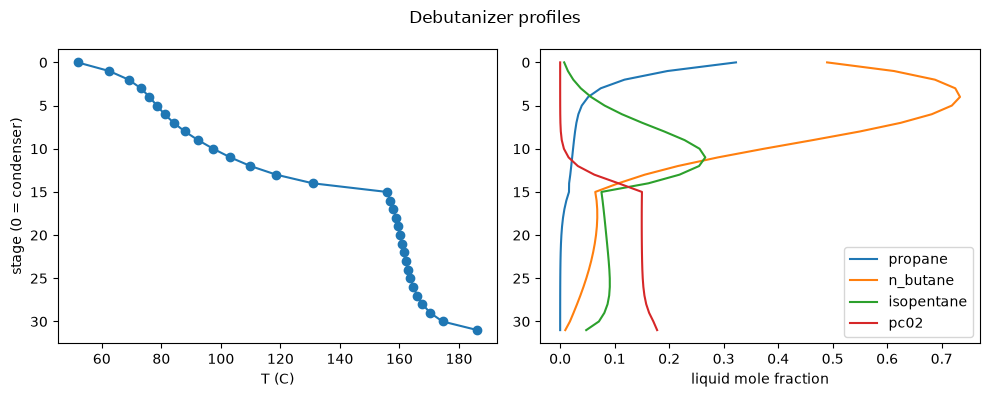

In [7]:
prof = bi["profiles"]
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
stage = np.arange(len(prof["T"]))
ax[0].plot(np.asarray(prof["T"]) - 273.15, stage, "o-")
ax[0].set_xlabel("T (C)"); ax[0].set_ylabel("stage (0 = condenser)"); ax[0].invert_yaxis()
x = np.asarray(prof["x"])
for n in ("propane", "n_butane", "isopentane", "pc02"):
    ax[1].plot(x[:, comps.names.index(n)], stage, label=n)
ax[1].set_xlabel("liquid mole fraction"); ax[1].invert_yaxis(); ax[1].legend()
fig.suptitle("Debutanizer profiles"); fig.tight_layout()

## 6. The naphtha splitter

The stabilised naphtha is split at 2.5 bar. It arrives at the debutanizer's bottom
temperature, so at 3 bar it is mostly vapor. That is why the splitter's condenser duty is
larger than its reboiler's. The light key is placed between the first two
cuts and the rest: the C5s and the first two cuts go overhead. Each product is held to 5 %
of the other's components.

In [8]:
t0 = time.time()
split = GasPlantColumn(splitter(comps, ("isopentane", "n_pentane") + tuple(cuts[:2]),
                                heavy_spec=("bottoms.x.light", 0.05),
                                light_spec=("distillate.x.heavy", 0.05),
                                n_trays=30, feed_tray=15, top_P=2.5e5))
lt_naphtha, hv_naphtha, si = split(dict(stab, P=3e5))
os_ = si["outputs"]
print(f"converged: {bool(si['converged'])} ({time.time() - t0:.0f} s)")

converged: True (9 s)


## 7. The plant in one table

Every product, every duty, and the material balance across the whole chain.

The deethanizer's reboiler is the largest duty. It heats the whole naphtha, entering as
lean oil at 40 C, to about 180 C. Preheating the naphtha against the debutanizer feed
would recover much of it. That is heat integration, which is out of scope here.

The balance is closed within each unit, so the products account for the feeds to round-off.
This plant has no recycle: in a real plant the sponge oil and the stabilised naphtha
recycled to the absorber would close a loop.

In [9]:
def mass(s):
    return float(jnp.sum(flows(s) * comps.MW)) * 3.6e-3  # g/s -> t/h


fg = fuel_gas(flows(fgas), comps)
rows = [("fuel gas", float(jnp.sum(flows(fgas))), mass(fgas), ""),
        ("acid gas (to sulfur recovery)", float(jnp.sum(flows(acid))), mass(acid), ""),
        ("LPG", float(jnp.sum(flows(lpg))), mass(lpg), ""),
        ("light naphtha", float(jnp.sum(flows(lt_naphtha))), mass(lt_naphtha),
         f"RVP {float(os_['distillate.rvp']) / 1e3:.0f} kPa" if "distillate.rvp" in os_ else ""),
        ("heavy naphtha", float(jnp.sum(flows(hv_naphtha))), mass(hv_naphtha), "")]
table(rows, ["product", "mol/s", "t/h", "note"])
print(f"fuel gas: LHV {float(fg['lhv_mass']) / 1e6:.1f} MJ/kg, {float(fg['heat']) / 1e6:.2f} MW, "
      f"H2S {float(fg['h2s_ppm']):.0f} ppm (mol)")

MW = lambda v: f"{float(v) / 1e6:.3f}"
table([("compressor", MW(ci["power"]), ""),
       ("deethanizer reboiler", MW(o["reboiler.duty"]), ""),
       ("debutanizer reboiler / condenser", MW(ob["reboiler.duty"]), MW(ob["condenser.duty"])),
       ("splitter reboiler / condenser", MW(os_["reboiler.duty"]), MW(os_["condenser.duty"]))],
      ["", "heat / power in (MW)", "heat out (MW)"])

into = flows(offgas) + flows(naphtha)
out = sum(flows(s) for s in (fgas, acid, lpg, lt_naphtha, hv_naphtha))
print(f"largest component imbalance across the plant: {float(jnp.max(jnp.abs(out - into))):.1e} mol/s "
      f"(on {float(jnp.sum(into)):.0f} mol/s)")

| product                       |      mol/s |        t/h | note       |
|-------------------------------|------------|------------|------------|
| fuel gas                      |   0.5557   |  0.06879   |            |
| acid gas (to sulfur recovery) |   0.004063 |  0.0004985 |            |
| LPG                           |  31.04     |  5.945     |            |
| light naphtha                 | 133.2      | 39.41      | RVP 57 kPa |
| heavy naphtha                 | 115        | 45.27      |            |

fuel gas: LHV 46.9 MJ/kg, 0.90 MW, H2S 857 ppm (mol)


|                                  |   heat / power in (MW) | heat out (MW)   |
|----------------------------------|------------------------|-----------------|
| compressor                       |                  0.014 |                 |
| deethanizer reboiler             |                  8.49  |                 |
| debutanizer reboiler / condenser |                  4.112 | 4.276           |
| splitter reboiler / condenser    |                  4.186 | 14.092          |

largest component imbalance across the plant: 7.9e-13 mol/s (on 280 mol/s)


## 8. Gradients through a column

Each column solve ends with one Newton step at the converged Jacobian, so `jax.grad`
through `solve_theta` returns the implicit-function derivative. It does not differentiate
the iterations. `gasplant_block` uses this to build delta vectors for the planner.

Here are the debutanizer's reboiler duty and the naphtha's RVP as functions of the C4 left
in the naphtha. This is the shift vector a planning model would use for "stabilise
harder".

In [10]:
th0 = debut.theta(deeth_btms)


def at_c4(c4):
    th = dict(th0, targets=dict(th0["targets"], **{"bottoms.x.C4": c4}))
    out = debut.solve_theta(th)["outputs"]
    return jnp.stack([out["reboiler.duty"], out["bottoms.rvp"], out["distillate.mol"]])


t0 = time.time()
J = jax.jacfwd(at_c4)(jnp.asarray(0.01))
h = 1e-4
fd = (at_c4(jnp.asarray(0.01 + h)) - at_c4(jnp.asarray(0.01 - h))) / (2 * h)
table([("reboiler duty (MW per mol frac)", float(J[0]) / 1e6, float(fd[0]) / 1e6),
       ("naphtha RVP (kPa per mol frac)", float(J[1]) / 1e3, float(fd[1]) / 1e3),
       ("LPG rate (mol/s per mol frac)", float(J[2]), float(fd[2]))],
      ["d/d(C4 in naphtha)", "implicit (AD)", "central FD"], floatfmt=".5g")
print(f"({time.time() - t0:.0f} s)")

| d/d(C4 in naphtha)              |   implicit (AD) |   central FD |
|---------------------------------|-----------------|--------------|
| reboiler duty (MW per mol frac) |         -81.708 |       -81.71 |
| naphtha RVP (kPa per mol frac)  |         303.37  |       303.37 |
| LPG rate (mol/s per mol frac)   |        -253.54  |      -253.54 |

(28 s)


Leaving more C4 in the naphtha costs less reboiler duty, raises its RVP and shrinks the LPG,
all as expected. The implicit and finite-difference derivatives agree to the digits
shown. `tests/refinery/test_gasplant.py` holds them to 1e-5 for the LPG purity, the naphtha
RVP and the reboiler duty, taken with respect to the reflux, the pressure and a feed
composition.

## Where to go next

- `docs/unit-operations-refinery.md` ("The saturated gas plant") has the column factories,
  the specs each one takes, and the gotchas.
- The IDAES cross-check is `tests/refinery/test_gasplant_validation.py`. It compares the
  debutanizer and the C3/C4 splitter against IDAES's `TrayColumn` on Peng-Robinson. That is
  an independent implementation of the same model, not an independent model.